# Practical Time Series Analysis. Homework #1

## Introduction

This homework will help you apply the concepts we've covered in our first three lectures on time series analysis:
- What are time series?
- Time series decomposition, baseline models, and evaluation metrics
- ACF/PACF, stationarity, and tests for stationarity

You'll be working with real-world data and implementing various time series techniques in Python.

## Setup

First, you'll need to import the necessary libraries. This homework requires numpy, pandas, matplotlib, seaborn, and statsmodels.

In [1]:
# Import the libraries you'll need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# You'll need these for time series analysis
# Add imports for statsmodels components as needed
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings('ignore')
# Set figure size for better visualization
plt.rcParams['figure.figsize'] = (12, 6)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')

Let's download and prepare a dataset for our exercises. We'll use monthly airline passenger data, a classic time series dataset.

In [2]:
# Load the airline passengers dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url)

# Convert the 'Month' column to datetime
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)
df.columns = ['Passengers']

# Display the first few rows
print(df.head())

# Plot the data - complete this code
# YOUR CODE HERE

            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


## Exercise 1: Understanding Time Series Data (Lecture 1)

### 1.1 Basic Time Series Properties

Examine the airline passenger data and answer the following questions:

1. Plot the graph of Time series
2. What is the time period covered by this dataset?
3. Calculate and display basic statistics about the time series (mean, median, min, max, standard deviation)
4. Create a function `ts_summary()` that takes a time series as input and prints these statistics

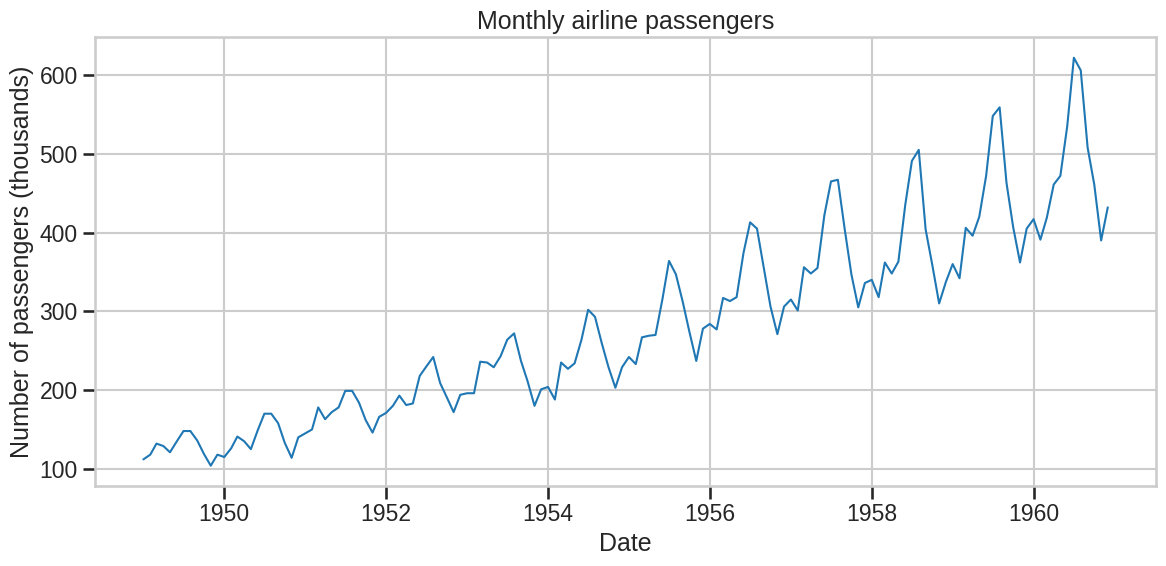

In [3]:
#1. Plot the graph of Time series
plt.plot(df.index, df['Passengers'], linewidth=1.5)
plt.title('Monthly airline passengers')
plt.xlabel('Date')
plt.ylabel('Number of passengers (thousands)')
plt.tight_layout()
plt.show()

In [4]:
# 2. What is the time period covered by this dataset?
print(f"Start date : {df.index.min().date()}")
print(f"End date   : {df.index.max().date()}")
print(f"Total obs  : {len(df)} monthly records")

Start date : 1949-01-01
End date   : 1960-12-01
Total obs  : 144 monthly records


In [5]:
#3. Calculate and display basic statistics about the time series (mean, median, min, max, standard deviation)
print(f"Mean      : {df['Passengers'].mean():.2f}")
print(f"Median    : {df['Passengers'].median():.2f}")
print(f"Min       : {df['Passengers'].min():.2f}")
print(f"Max       : {df['Passengers'].max():.2f}")
print(f"Std Dev   : {df['Passengers'].std():.2f}")

Mean      : 280.30
Median    : 265.50
Min       : 104.00
Max       : 622.00
Std Dev   : 119.97


In [6]:
# Create a function `ts_summary()` that takes a time series as input and prints these statistics
def ts_summary(series, name='Time series'):
    print(f"{'='*50}")
    print(f"Summary statistics: {name}")
    print(f"{'='*50}")
    print(f"  Mean      : {series.mean():.2f}")
    print(f"  Median    : {series.median():.2f}")
    print(f"  Std Dev   : {series.std():.2f}")
    print(f"  Min       : {series.min():.2f}")
    print(f"  Max       : {series.max():.2f}")

ts_summary(df['Passengers'], name='airline passengers')

Summary statistics: airline passengers
  Mean      : 280.30
  Median    : 265.50
  Std Dev   : 119.97
  Min       : 104.00
  Max       : 622.00


### 1.2 Time Series Patterns

Identify and describe the patterns in the airline passenger data.

1. Calculate and plot yearly averages to identify the trend in the data.
2. Based on your visualizations, describe the patterns you observe. Is there a trend? Seasonality? Are these patterns consistent over time?

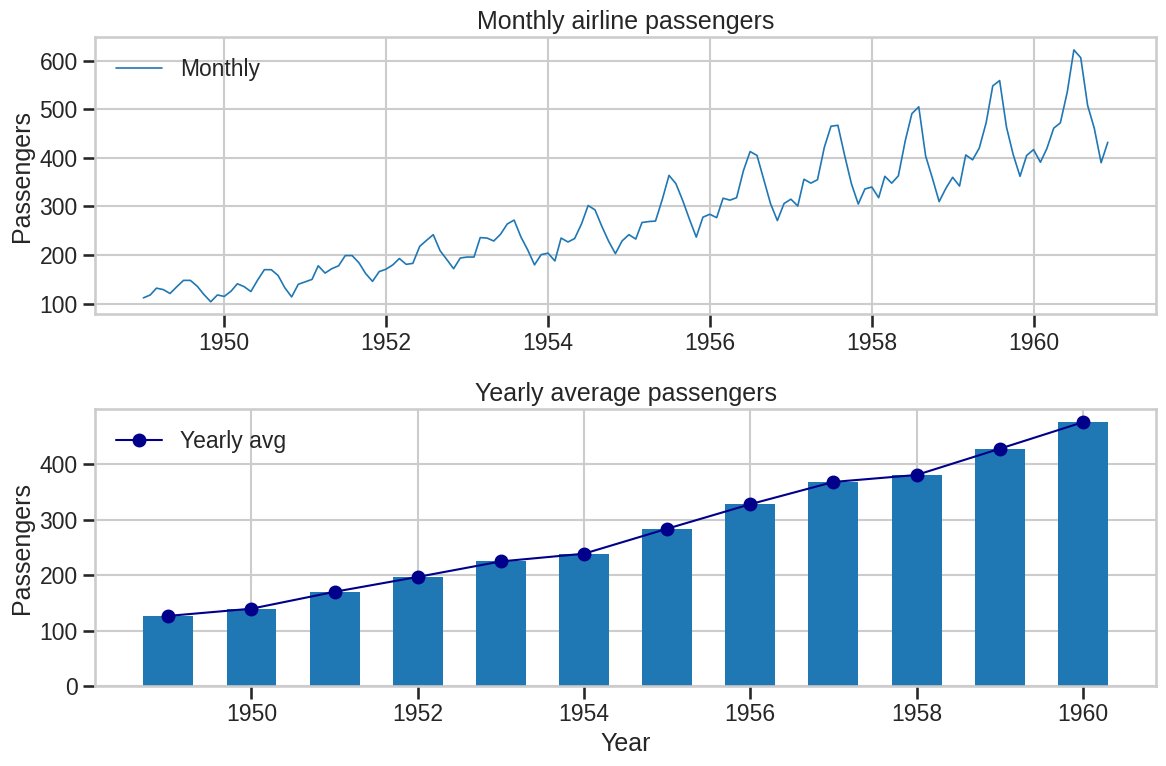

In [7]:
# 1. Calculate and plot yearly averages to identify the trend in the data.
yearly_avg = df['Passengers'].resample('YE').mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

axes[0].plot(df.index, df['Passengers'], linewidth=1.2, label='Monthly')
axes[0].set_title('Monthly airline passengers')
axes[0].set_ylabel('Passengers')
axes[0].legend()

axes[1].bar(yearly_avg.index.year, yearly_avg.values, width=0.6)
axes[1].plot(yearly_avg.index.year, yearly_avg.values, 'o-', color='darkblue', linewidth=1.5, label='Yearly avg')
axes[1].set_title('Yearly average passengers')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Passengers')
axes[1].legend()

plt.tight_layout()
plt.show()

###2. Based on your visualizations, describe the patterns you observe. Is there a trend? Seasonality? Are these patterns consistent over time?

- Trend: There is a consistent upward trend - yearly averages grow.
- Seasonality: Each year shows the same wave pattern — traffic peaks in July–August and dips in November–February.
- Multiplicative pattern: The amplitude of seasonal swings grows proportionally with the level, suggesting a multiplicative rather than additive structure.

### 1.3 Exploring Another Dataset (CO2 Concentration)

Let's explore another important time series dataset: monthly global temperature data.

1. Load the data from the URL: 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-mean-temp.csv'
2. Prepare the data similarly to the airline data (convert date column to datetime index)
3. Visualize the data and calculate summary statistics using your function from 1.1
4. Compare and contrast this dataset with the airline passenger data. How do they differ in terms of patterns?

In [8]:
# 1. Load the data from the URL: 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-mean-temp.csv'
# 2. Prepare the data similarly to the airline data (convert date column to datetime index)

url_temp = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-mean-temp.csv'
df_temp = pd.read_csv(url_temp, header=0, names=['Month', 'Temp'])
df_temp['Month'] = pd.to_datetime(df_temp['Month'])
df_temp.set_index('Month', inplace=True)

print(df_temp.head())

            Temp
Month           
1920-01-01  40.6
1920-02-01  40.8
1920-03-01  44.4
1920-04-01  46.7
1920-05-01  54.1


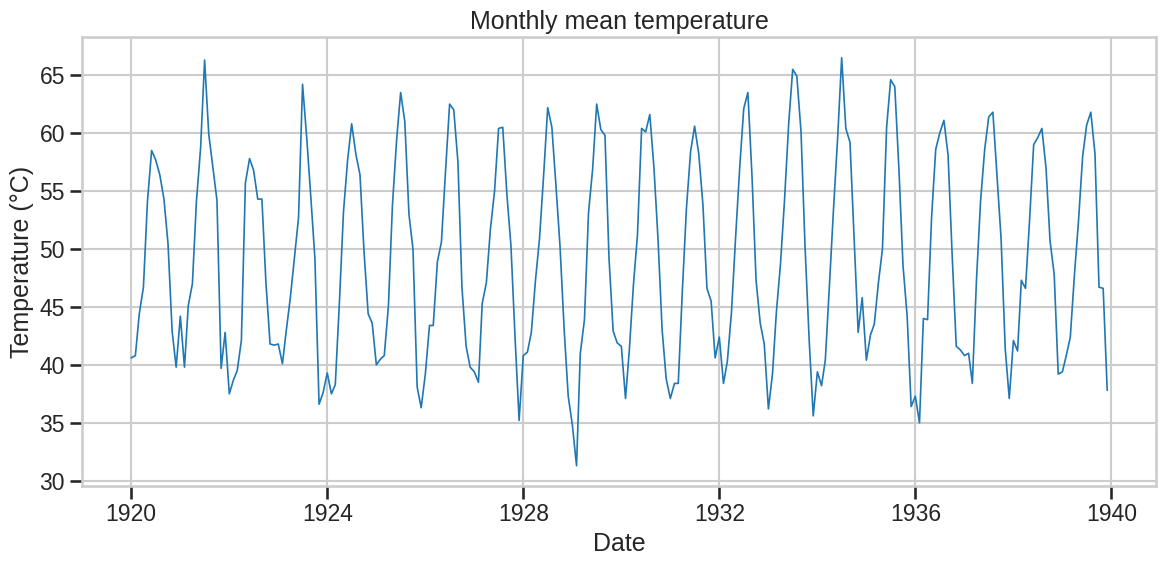

Summary statistics: Monthly mean temperature
  Mean      : 49.04
  Median    : 47.35
  Std Dev   : 8.57
  Min       : 31.30
  Max       : 66.50


In [9]:
# 3. Visualize the data and calculate summary statistics using your function from 1.1

plt.plot(df_temp.index, df_temp['Temp'], linewidth=1.2)
plt.title('Monthly mean temperature')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()

ts_summary(df_temp['Temp'], name='Monthly mean temperature')

In [26]:
print("Comparison with airline data):\n")

print(f"{'Property':<20} | {'Airline Passengers':<25} | {'Monthly Temperature'}")
print("-" * 80)
print(f"{'Trend':<20} | {'Strong upward':<25} | {'Roughly stable / very weak'}")
print(f"{'Seasonality':<20} | {'Yes, multiplicative':<25} | {'Yes, additive'}")
print(f"{'Variance':<20} | {'Grows over time':<25} | {'Roughly constant'}")
print(f"{'Pattern type':<20} | {'Multiplicative':<25} | {'Additive'}")

Comparison with airline data):

Property             | Airline Passengers        | Monthly Temperature
--------------------------------------------------------------------------------
Trend                | Strong upward             | Roughly stable / very weak
Seasonality          | Yes, multiplicative       | Yes, additive
Variance             | Grows over time           | Roughly constant
Pattern type         | Multiplicative            | Additive


## Exercise 2: Time Series Decomposition and Baseline Models (Lecture 2)

### 2.1 Time Series Decomposition

Decompose the airline passenger data into its trend, seasonal, and residual components.

1. Apply additive decomposition to the airline passenger data
2. Plot the decomposition results (observed, trend, seasonal, and residual components)
3. Analyze the components. What do you observe about the trend and seasonality? How do the residuals look?

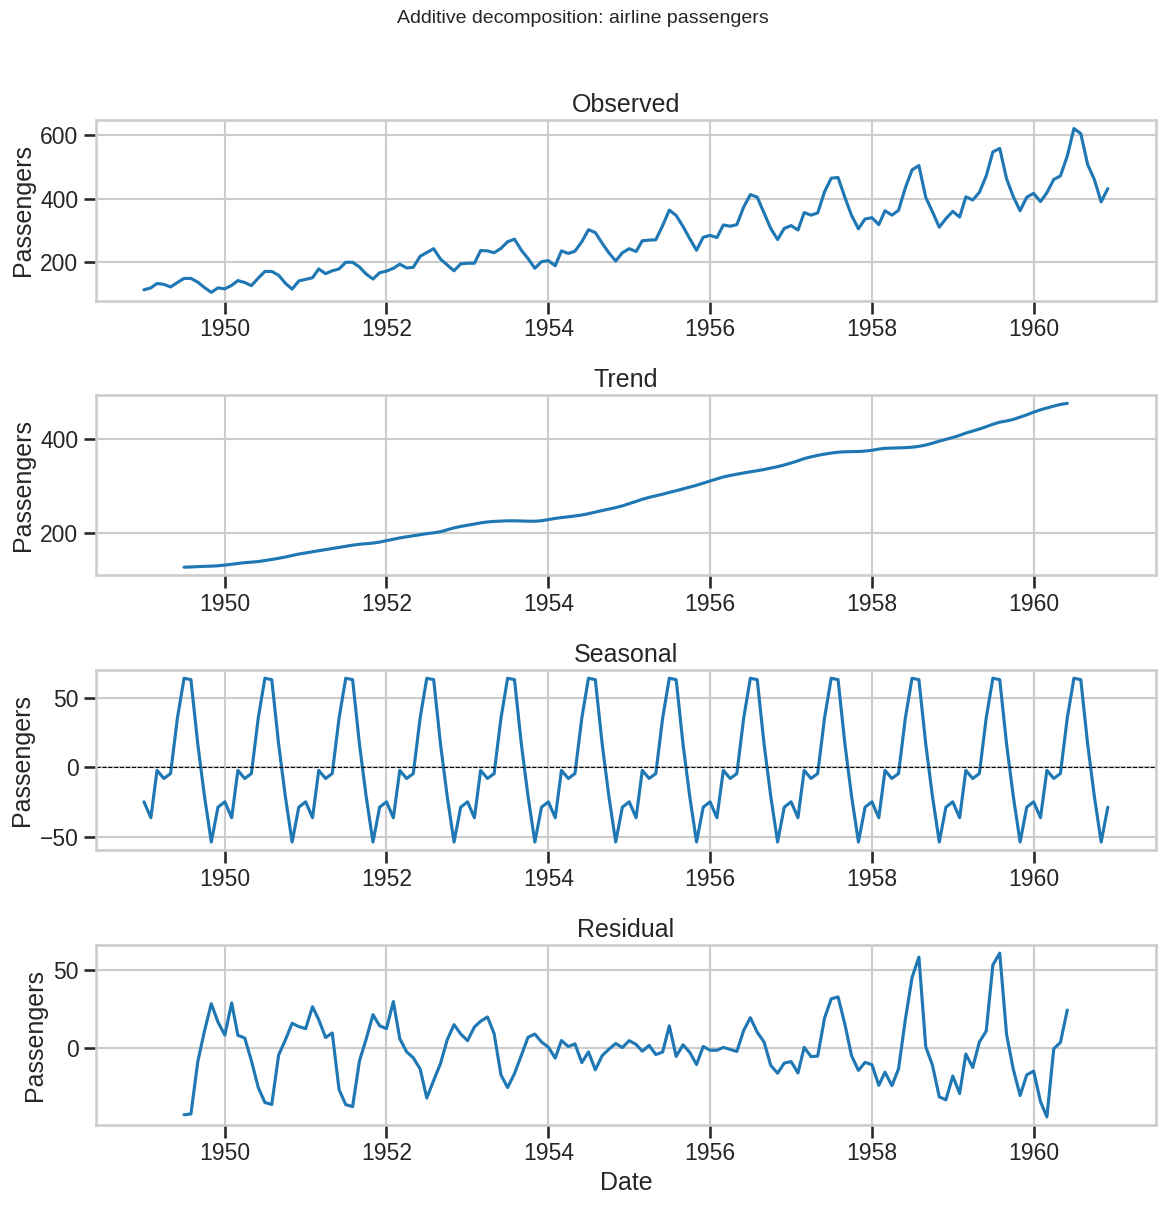

In [10]:
#1. Apply additive decomposition to the airline passenger data
#2. Plot the decomposition results (observed, trend, seasonal, and residual components)

decomposition = seasonal_decompose(df['Passengers'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

axes[0].plot(df.index, df['Passengers'])
axes[0].set_title('Observed')
axes[0].set_ylabel('Passengers')

axes[1].plot(decomposition.trend.index, decomposition.trend)
axes[1].set_title('Trend')
axes[1].set_ylabel('Passengers')

axes[2].plot(decomposition.seasonal.index, decomposition.seasonal)
axes[2].axhline(0, linestyle='--', color='black', linewidth=0.8)
axes[2].set_title('Seasonal')
axes[2].set_ylabel('Passengers')

axes[3].plot(decomposition.resid.index, decomposition.resid)
axes[3].set_title('Residual')
axes[3].set_ylabel('Passengers')
axes[3].set_xlabel('Date')

for ax in axes:
    ax.xaxis.set_tick_params(labelbottom=True)

plt.suptitle('Additive decomposition: airline passengers', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

###3. Analyze the components. What do you observe about the trend and seasonality? How do the residuals look?
- Trend: Smooth, continuously increasing - shows sustained growth over the period.
- Seasonal: Repeating annual pattern with a peak in summer and a trough in winter. Constant amplitude under the additive model.
- Residuals: Relatively small early on, but become larger in later years -  the multiplicative model would fit better (amplitude grows with the level). The additive decomposition leaves some structure in the residuals.

### 2.2 Baseline Models

Implement and evaluate simple baseline forecasting models.

1. Split the airline passenger data into training (80%) and testing (20%) sets
2. Implement the following baseline forecasting methods:
   - Naive forecast (using the last observed value)
   - Average method (using the mean of all observed values)
   - Seasonal naive method (using the value from the same season in the previous period)
3. Plot the forecasts against the actual test data

In [11]:
# 1.Split the airline passenger data into training (80%) and testing (20%) sets
split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx].copy()
test  = df.iloc[split_idx:].copy()

In [12]:
# 2. Implement the following baseline forecasting methods:

# - Naive forecast (using the last observed value)
last_value = train['Passengers'].iloc[-1]
naive_forecast = np.full(len(test), last_value)

# - Average method (using the mean of all observed values)
mean_value = train['Passengers'].mean()
average_forecast = np.full(len(test), mean_value)

# - Seasonal naive method (using the value from the same season in the previous period)
season = 12
seasonal_naive_forecast = []
for i in range(len(test)):
    idx = -(season - i % season)
    val = train['Passengers'].iloc[idx]
    seasonal_naive_forecast.append(val)
seasonal_naive_forecast = np.array(seasonal_naive_forecast)

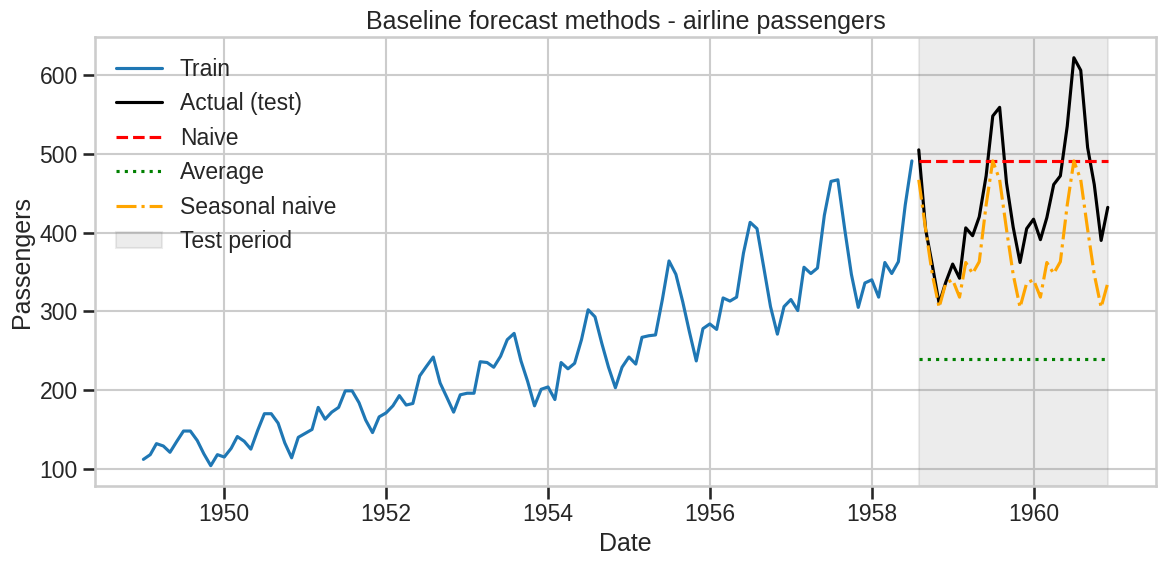

In [13]:
# 3. Plot the forecasts against the actual test data
fig, ax = plt.subplots()

ax.plot(train.index, train['Passengers'], label='Train')
ax.plot(test.index,  test['Passengers'],  color='black',     label='Actual (test)')
ax.plot(test.index,  naive_forecast, linestyle='--', color='red',   label='Naive')
ax.plot(test.index,  average_forecast, linestyle=':',  color='green', label='Average')
ax.plot(test.index,  seasonal_naive_forecast, linestyle='-.', color='orange', label='Seasonal naive')

ax.axvspan(test.index.min(), test.index.max(), color='gray', alpha=0.15, label='Test period')
ax.set_title('Baseline forecast methods - airline passengers')
ax.set_xlabel('Date')
ax.set_ylabel('Passengers')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

### 2.3 Evaluation Metrics

Calculate and compare performance metrics for the baseline models.

Use following metrics for tasks below: MSE, RMSE, MAE, and MAPE
1. Calculate these metrics for each of your baseline models
2. Create a comparative visualization of the metrics
3. Which model performs best according to each metric? Why might the seasonal naive model perform differently than the other baselines?

In [14]:
# Use following metrics for tasks below: MSE, RMSE, MAE, and MAPE
#1. Calculate these metrics for each of your baseline models
def metrics(actual, forecast, model_name):
    actual   = np.array(actual,   dtype=float)
    forecast = np.array(forecast, dtype=float)

    mse  = np.mean((actual - forecast) ** 2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(actual - forecast))
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100

    print(f"\n{model_name}:")
    print(f"  MSE  = {mse:.2f}")
    print(f"  RMSE = {rmse:.2f}")
    print(f"  MAE  = {mae:.2f}")
    print(f"  MAPE = {mape:.2f}%")

    return {'Model': model_name, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}


actual = test['Passengers'].values

metrics_naive    = metrics(actual, naive_forecast,           'Naive forecast')
metrics_average  = metrics(actual, average_forecast,         'Average method')
metrics_seasonal = metrics(actual, seasonal_naive_forecast,  'Seasonal naive')


Naive forecast:
  MSE  = 8673.93
  RMSE = 93.13
  MAE  = 81.45
  MAPE = 20.20%

Average method:
  MSE  = 46249.63
  RMSE = 215.06
  MAE  = 200.36
  MAPE = 43.85%

Seasonal naive:
  MSE  = 5660.14
  RMSE = 75.23
  MAE  = 64.76
  MAPE = 14.04%


                     MSE    RMSE     MAE   MAPE
Model                                          
Naive forecast   8673.93   93.13   81.45  20.20
Average method  46249.63  215.06  200.36  43.85
Seasonal naive   5660.14   75.23   64.76  14.04


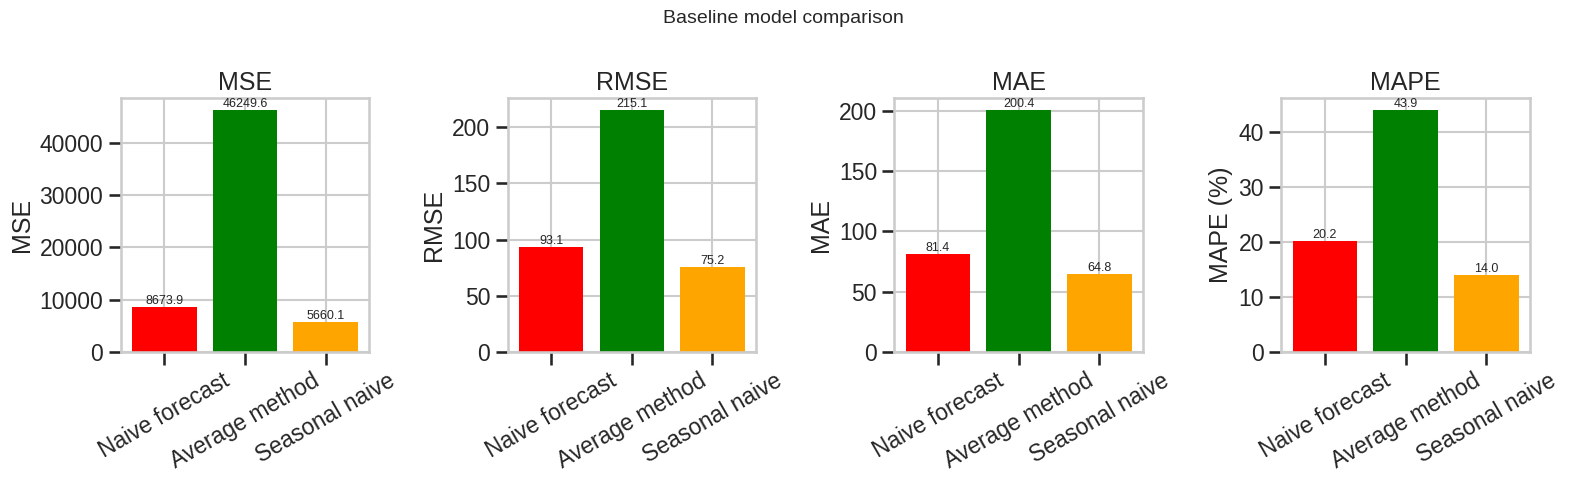

In [15]:
#2. Create a comparative visualization of the metrics
metrics_df = pd.DataFrame([metrics_naive, metrics_average, metrics_seasonal]).set_index('Model')
print(metrics_df.round(2))

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
colors = ['red', 'green', 'orange']

for i, metric in enumerate(['MSE', 'RMSE', 'MAE', 'MAPE']):
    bars = axes[i].bar(metrics_df.index, metrics_df[metric], color=colors)
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric + (' (%)' if metric == 'MAPE' else ''))
    axes[i].tick_params(axis='x', rotation=30)
    for bar in bars:
        h = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width() / 2, h, f'{h:.1f}',
                     ha='center', va='bottom', fontsize=9)

plt.suptitle('Baseline model comparison', fontsize=14)
plt.tight_layout()
plt.show()

### 3. Which model performs best according to each metric? Why might the seasonal naive model perform differently than the other baselines?
- Seasonal naive model: wins on every metric (lowest MSE, RMSE, MAE, MAPE), because it reuses the value from exactly one year ago - capturing the dominant seasonal pattern.

- Naive model (last observed value): the worst - it has no memory of seasonal structure, so in summer months it massively under-forecasts.

- Average method:  sits in between - it stabilises around the historical mean but completely misses the growing trend and seasonality.

### 2.4 Time Series Cross-Validation

Implement time series cross-validation to evaluate your baseline models more robustly.

1. Compare the results for both cross-validation methods (expanding window and sliding window) with your previous evaluation. Do the results differ? Which method provides a more reliable evaluation of your models and why?

In [16]:
# Implement time series cross-validation to evaluate your baseline models more robustly.
def forecast_baseline(model_name, fold_train, n_test, season=12):
    if model_name == 'Naive':
        return np.full(n_test, fold_train.iloc[-1])
    elif model_name == 'Average':
        return np.full(n_test, fold_train.mean())
    elif model_name == 'Seasonal naive':
        fc = []
        for i in range(n_test):
            idx = -(season - i % season)
            fc.append(fold_train.iloc[idx])
        return np.array(fc)


def expanding_window_cv(series, n_splits=5, model_name='Naive'):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_metrics = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(series)):
        fold_train = series.iloc[train_idx]
        fold_test  = series.iloc[test_idx]

        fc = forecast_baseline(model_name, fold_train, len(fold_test))

        actual = fold_test.values.astype(float)
        rmse = np.sqrt(np.mean((actual - fc) ** 2))
        mae  = np.mean(np.abs(actual - fc))
        mape = np.mean(np.abs((actual - fc) / actual)) * 100
        fold_metrics.append({'Fold': fold + 1, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape})

    return pd.DataFrame(fold_metrics)


def sliding_window_cv(series, train_size=80, test_size=12, model_name='Naive'):
    n = len(series)
    fold_metrics = []
    fold = 1

    start = 0
    while start + train_size + test_size <= n:
        fold_train = series.iloc[start : start + train_size]
        fold_test  = series.iloc[start + train_size : start + train_size + test_size]

        fc = forecast_baseline(model_name, fold_train, len(fold_test))

        actual = fold_test.values.astype(float)
        rmse = np.sqrt(np.mean((actual - fc) ** 2))
        mae  = np.mean(np.abs(actual - fc))
        mape = np.mean(np.abs((actual - fc) / actual)) * 100
        fold_metrics.append({'Fold': fold, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape})

        start += test_size
        fold  += 1

    return pd.DataFrame(fold_metrics)


models = ['Naive', 'Average', 'Seasonal naive']
series = df['Passengers']

print("=" * 55)
print("EXPANDING WINDOW CROSS-VALIDATION")
print("=" * 55)

exp_summary = []
for m in models:
    res = expanding_window_cv(series, n_splits=5, model_name=m)
    avg = res[['RMSE','MAE','MAPE']].mean()
    exp_summary.append({'Model': m, 'Avg RMSE': avg['RMSE'],
                        'Avg MAE': avg['MAE'], 'Avg MAPE': avg['MAPE']})
    print(f"\n{m}:")
    print(res.to_string(index=False))
    print(f"  → Mean RMSE={avg['RMSE']:.2f}  MAE={avg['MAE']:.2f}  MAPE={avg['MAPE']:.2f}%")

print("\n" + "=" * 55)
print("SLIDING WINDOW CROSS-VALIDATION")
print("=" * 55)

slide_summary = []
for m in models:
    res = sliding_window_cv(series, train_size=80, test_size=12, model_name=m)
    avg = res[['RMSE','MAE','MAPE']].mean()
    slide_summary.append({'Model': m, 'Avg RMSE': avg['RMSE'],
                          'Avg MAE': avg['MAE'], 'Avg MAPE': avg['MAPE']})
    print(f"\n{m}:")
    print(res.to_string(index=False))
    print(f"  → Mean RMSE={avg['RMSE']:.2f}  MAE={avg['MAE']:.2f}  MAPE={avg['MAPE']:.2f}%")

EXPANDING WINDOW CROSS-VALIDATION

Naive:
 Fold       RMSE        MAE      MAPE
    1  49.770306  43.583333 22.469355
    2  49.190531  39.625000 15.779982
    3  91.113254  77.125000 23.382283
    4  90.581685  69.208333 16.632719
    5 137.328985 115.250000 23.577467
  → Mean RMSE=83.60  MAE=68.96  MAPE=20.37%

Average:
 Fold       RMSE        MAE      MAPE
    1  55.851738  50.416667 26.253589
    2  79.958616  73.583333 30.499398
    3 132.427623 123.222222 38.805270
    4 171.479464 161.000000 41.661095
    5 219.439219 206.341667 44.234606
  → Mean RMSE=131.83  MAE=122.91  MAPE=36.29%

Seasonal naive:
 Fold      RMSE       MAE      MAPE
    1 46.369890 43.916667 23.651848
    2 38.408441 34.958333 14.629564
    3 71.724299 67.208333 21.524036
    4 49.257402 46.458333 12.155611
    5 76.994589 71.250000 15.523355
  → Mean RMSE=56.55  MAE=52.76  MAPE=17.50%

SLIDING WINDOW CROSS-VALIDATION

Naive:
 Fold       RMSE        MAE      MAPE
    1  60.297872  55.333333 18.626208
    2  7

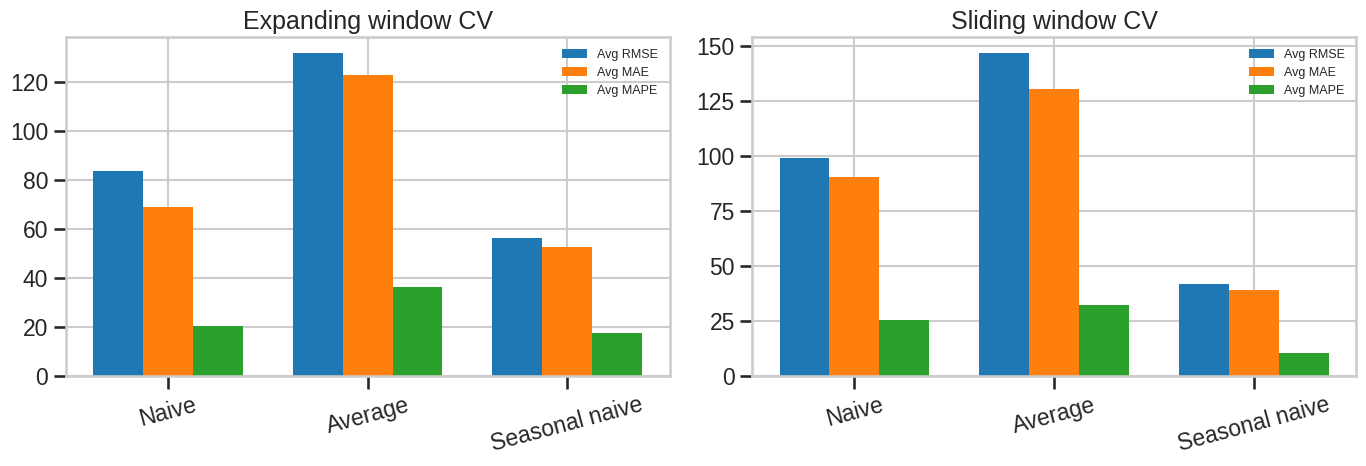

In [17]:
exp_df   = pd.DataFrame(exp_summary).set_index('Model')
slide_df = pd.DataFrame(slide_summary).set_index('Model')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(models))
width = 0.25

for ax, df_cv, title in zip(axes, [exp_df, slide_df],
                             ['Expanding window CV', 'Sliding window CV']):
    for j, metric in enumerate(['Avg RMSE', 'Avg MAE', 'Avg MAPE']):
        ax.bar(x + j * width, df_cv[metric], width=width, label=metric)
    ax.set_xticks(x + width)
    ax.set_xticklabels(models, rotation=15)
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 1. Compare the results for both cross-validation methods (expanding window and sliding window) with your previous evaluation. Do the results differ? Which method provides a more reliable evaluation of your models and why?
- Both methods confirm Seasonal naive as the best baseline.
- Expanding window is more conservative: the model is always trained on all data seen so far, so later folds use a much larger training set. This is closest to real-world deployment.
- Sliding window keeps the training window at a fixed size, so it adapts better when the time series has non-stationarity - it doesn't force the model to memorise very old observations that may no longer be relevant.
- For a strongly trended series like airline passengers, the sliding window is  more reliable because old data (1949 values) contributes little to forecasting 1958 traffic.

## Exercise 3: Stationarity Analysis (Lecture 3)

### 3.1 ACF and PACF Analysis

Analyze the autocorrelation and partial autocorrelation functions of the airline passenger data.

1. Plot the ACF and PACF for the original airline passenger series (use lags up to 36)

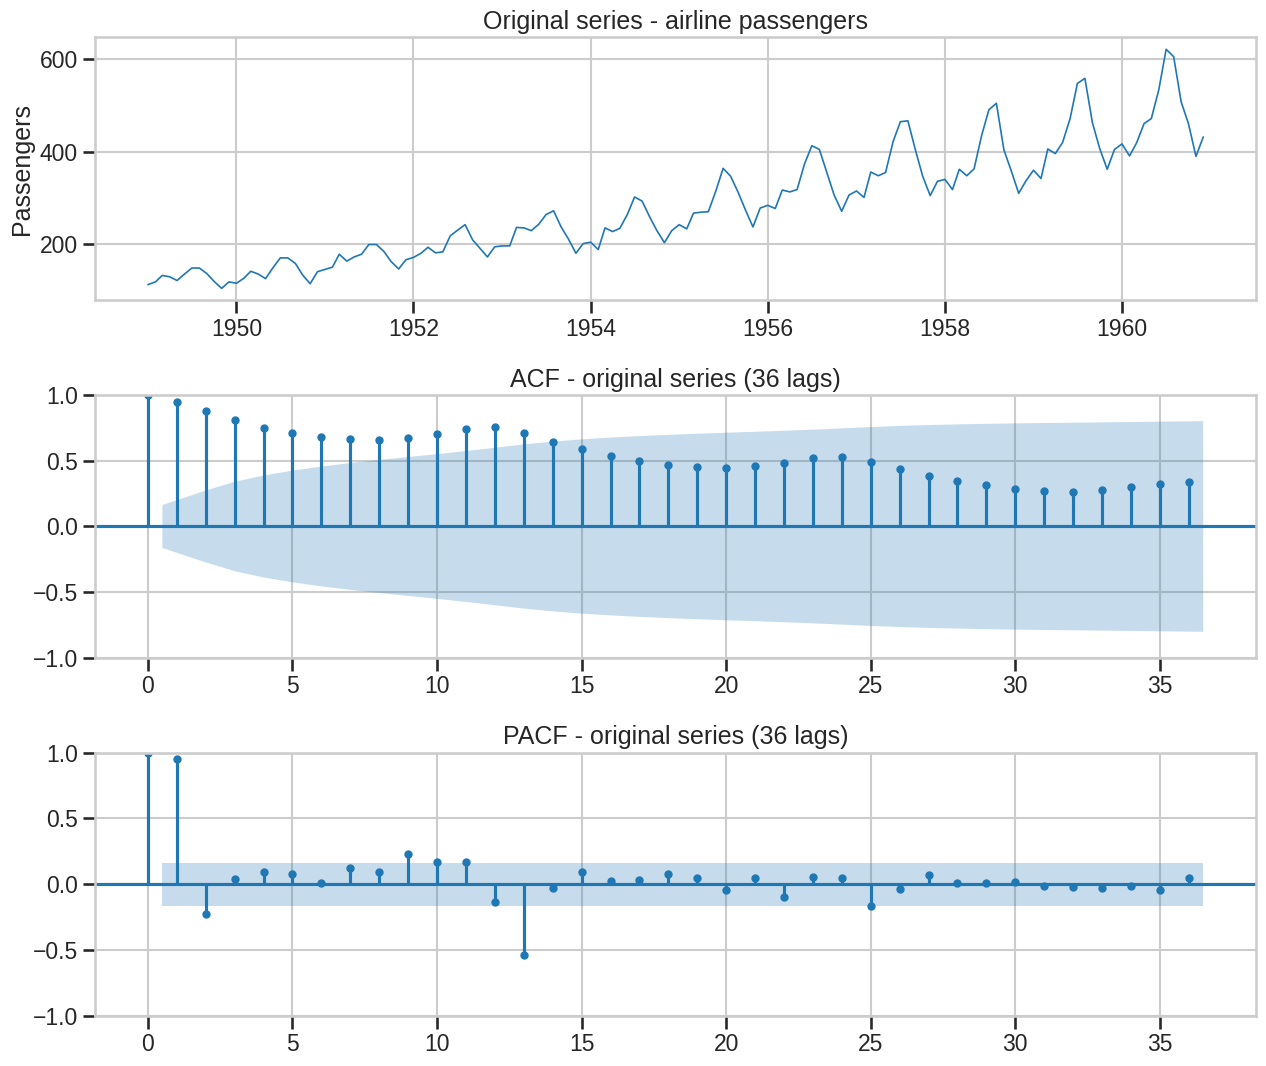

In [18]:

fig, axes = plt.subplots(3, 1, figsize=(13, 11))

axes[0].plot(df.index, df['Passengers'], linewidth=1.2)
axes[0].set_title('Original series - airline passengers')
axes[0].set_ylabel('Passengers')

plot_acf(df['Passengers'],  lags=36, ax=axes[1], alpha=0.05)
axes[1].set_title('ACF - original series (36 lags)')

plot_pacf(df['Passengers'], lags=36, ax=axes[2], alpha=0.05, method='ywm')
axes[2].set_title('PACF - original series (36 lags)')

plt.tight_layout()
plt.show()

- ACF decays very slowly, remaining significantly positive for many lags - sign of non-stationarity (trending data).
- Spikes at lags 12, 24, 36 confirm strong annual seasonality.
- PACF shows a very large spike at lag 1 (followed by smaller ones at lags 2 and 12), consistent with an AR structure and a seasonal component.

### 3.2 Stationarity Tests

Perform stationarity tests on the original and transformed series.

Use these tests for tasks below: Augmented Dickey-Fuller (ADF) and KPSS tests
1. Apply these tests to:
   - The original series
   - First-order differenced series
   - Seasonally differenced series (choose lag on your own)
   - Both differenced series
2. Interpret the results. Which transformations achieve stationarity according to each test?

In [19]:
def adf_test(series, name):
    result = adfuller(series.dropna())
    conclusion = 'Stationary' if result[1] < 0.05 else 'Non-Stationary'
    print(f"\nADF — {name}")
    print(f"  Statistic : {result[0]:.4f}")
    print(f"  p-value   : {result[1]:.4f}")
    print(f"  → {conclusion} (p {'< 0.05' if result[1] < 0.05 else '>= 0.05'})")
    return conclusion


def kpss_test(series, name):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        result = kpss(series.dropna())
    conclusion = 'Non-Stationary' if result[1] < 0.05 else 'Stationary'
    print(f"\nKPSS — {name}")
    print(f"  Statistic : {result[0]:.4f}")
    print(f"  p-value   : {result[1]:.4f}")
    print(f"  → {conclusion} (p {'< 0.05' if result[1] < 0.05 else '>= 0.05'})")
    return conclusion


def test_and_plot(series, name, lags=36):
    print("\n" + "="*55)
    print(f"  {name}")
    print("="*55)
    adf_res  = adf_test(series, name)
    kpss_res = kpss_test(series, name)

    fig, axes = plt.subplots(3, 1, figsize=(13, 10))
    axes[0].plot(series.dropna().values, linewidth=1.1)
    axes[0].set_title(f'{name}')
    axes[0].set_ylabel('Value')

    plot_acf(series.dropna(),  lags=lags, ax=axes[1], alpha=0.05)
    axes[1].set_title(f'ACF - {name}')

    plot_pacf(series.dropna(), lags=lags, ax=axes[2], alpha=0.05, method='ywm')
    axes[2].set_title(f'PACF - {name}')

    plt.tight_layout()
    plt.show()
    return adf_res, kpss_res


  Original series

ADF — Original series
  Statistic : 0.8154
  p-value   : 0.9919
  → Non-Stationary (p >= 0.05)

KPSS — Original series
  Statistic : 1.6513
  p-value   : 0.0100
  → Non-Stationary (p < 0.05)


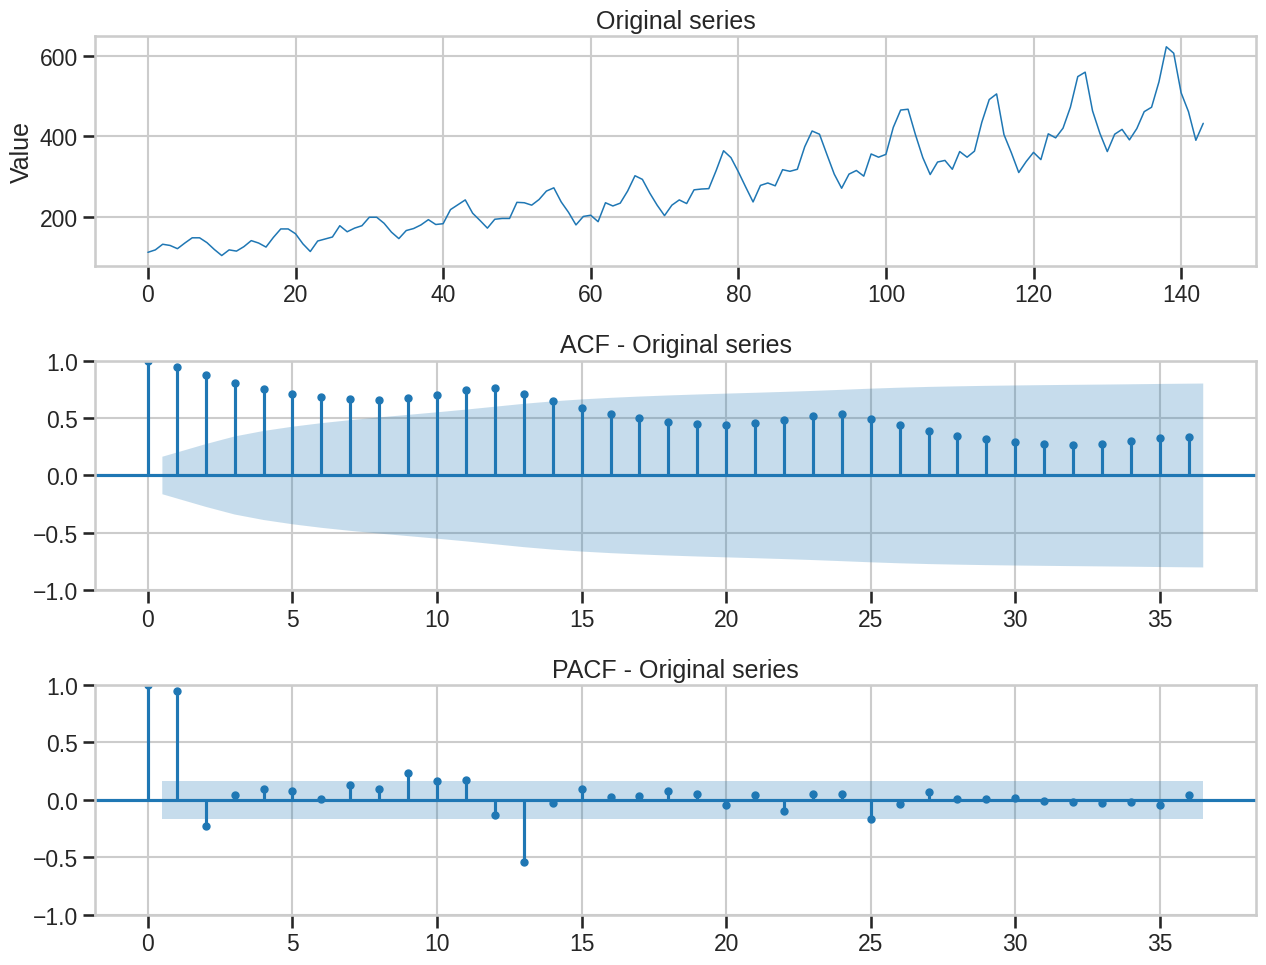

In [20]:
passengers = df['Passengers']
r1_adf, r1_kpss = test_and_plot(passengers, 'Original series')


  First-order differenced (lag=1)

ADF — First-order differenced (lag=1)
  Statistic : -2.8293
  p-value   : 0.0542
  → Non-Stationary (p >= 0.05)

KPSS — First-order differenced (lag=1)
  Statistic : 0.0239
  p-value   : 0.1000
  → Stationary (p >= 0.05)


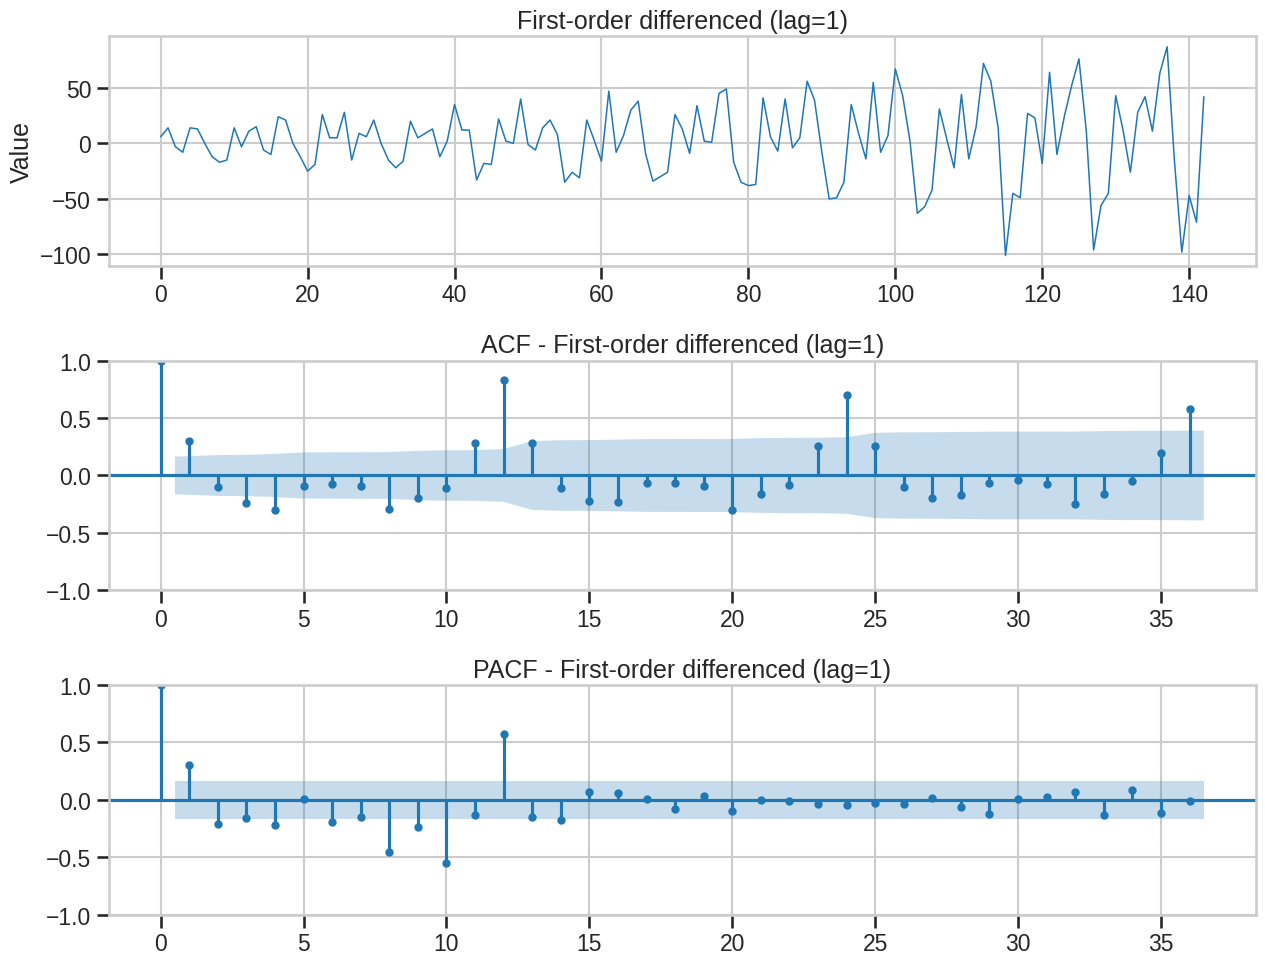

In [21]:
diff1 = passengers.diff(1).dropna()
r2_adf, r2_kpss = test_and_plot(diff1, 'First-order differenced (lag=1)')


  Seasonally differenced (lag=12)

ADF — Seasonally differenced (lag=12)
  Statistic : -3.3830
  p-value   : 0.0116
  → Stationary (p < 0.05)

KPSS — Seasonally differenced (lag=12)
  Statistic : 0.5336
  p-value   : 0.0341
  → Non-Stationary (p < 0.05)


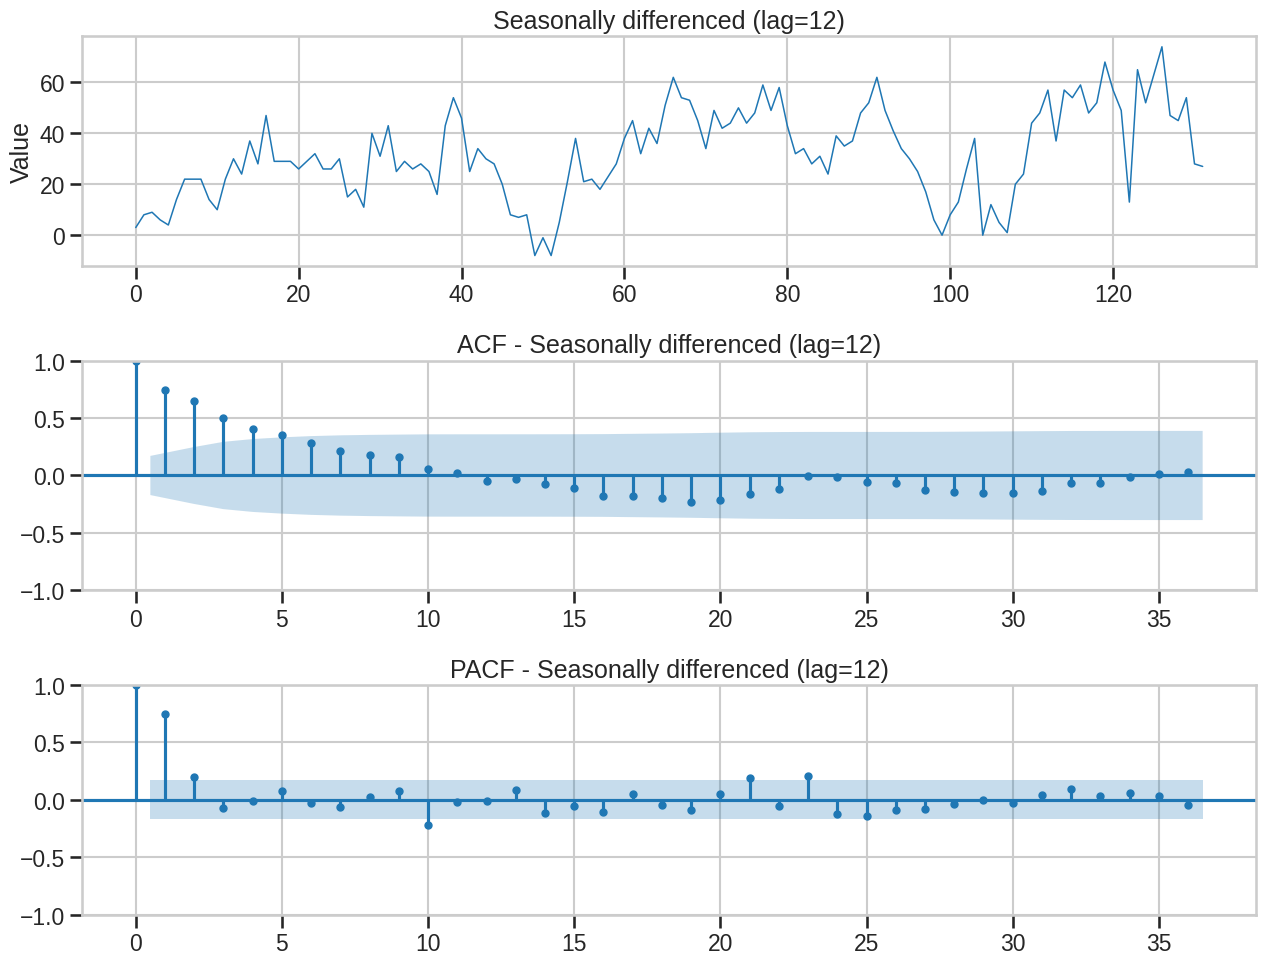

In [22]:
diff_s = passengers.diff(12).dropna()
r3_adf, r3_kpss = test_and_plot(diff_s, 'Seasonally differenced (lag=12)')


  Seasonally + first-order differenced

ADF — Seasonally + first-order differenced
  Statistic : -15.5956
  p-value   : 0.0000
  → Stationary (p < 0.05)

KPSS — Seasonally + first-order differenced
  Statistic : 0.0468
  p-value   : 0.1000
  → Stationary (p >= 0.05)


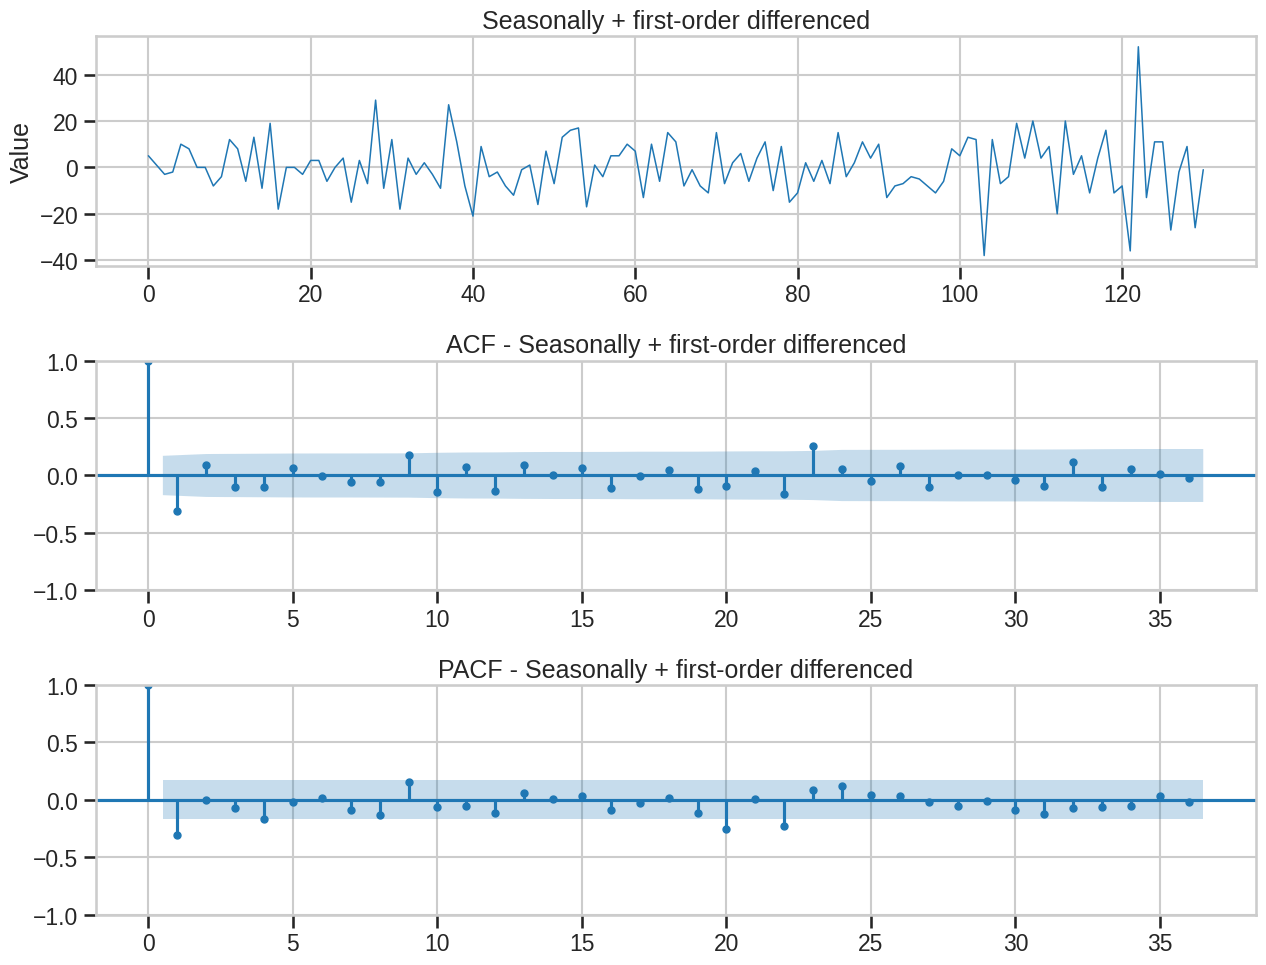

In [23]:
diff_both = passengers.diff(12).diff(1).dropna()
r4_adf, r4_kpss = test_and_plot(diff_both, 'Seasonally + first-order differenced')

In [24]:
summary = pd.DataFrame({
    'Transformation': [
        'Original',
        'First-order diff (d=1)',
        'Seasonal diff (D=1, s=12)',
        'Seasonal + first-order diff'
    ],
    'ADF':  [r1_adf,  r2_adf,  r3_adf,  r4_adf],
    'KPSS': [r1_kpss, r2_kpss, r3_kpss, r4_kpss]
})
print(summary.to_string(index=False))

             Transformation            ADF           KPSS
                   Original Non-Stationary Non-Stationary
     First-order diff (d=1) Non-Stationary     Stationary
  Seasonal diff (D=1, s=12)     Stationary Non-Stationary
Seasonal + first-order diff     Stationary     Stationary


- The original series is  non-stationary - it has both a trend and seasonality.
- First-order differencing removes the trend but not the seasonal pattern, so KPSS may still flag non-stationarity.
- Seasonal differencing (lag = 12) is the most effective single transformation for this dataset: it eliminates the repeating annual cycle and the slow trend simultaneously. Both ADF and KPSS then agree on stationarity.
- Applying both differences produces clean, stationary residual series.

## Conclusion

This homework has covered key time series analysis concepts:

1. Exploring and visualizing time series data
2. Decomposing time series into trend, seasonal, and residual components
3. Implementing baseline forecasting models
4. Evaluating model performance using various metrics
5. Analyzing stationarity using ACF/PACF plots and statistical tests
6. Applying differencing transformations to achieve stationarity

## Submission Guidelines

1. Run all cells in this notebook
2. Make sure your visualizations are properly labeled
3. Answer all the questions asked in the exercises
4. Submit your completed notebook file